# Exploratory Data Analysis: E-Commerce Demand Prediction Dataset

This notebook performs comprehensive exploratory data analysis on the e-commerce dataset to understand patterns, distributions, and relationships in the data.

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
df = pd.read_csv('data_new.csv', encoding='latin-1')
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (541909, 8)


## 2. Dataset Overview

In [2]:
# Display basic information
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Records: {len(df):,}")
print(f"Number of Features: {len(df.columns)}")
print(f"\nColumn Names and Types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
df.head()

DATASET OVERVIEW

Dataset Shape: (541909, 8)
Number of Records: 541,909
Number of Features: 8

Column Names and Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 3. Missing Values Analysis

MISSING VALUES ANALYSIS
     Column  Missing_Count  Missing_Percentage
 CustomerID         135080               24.93
Description           1454                0.27


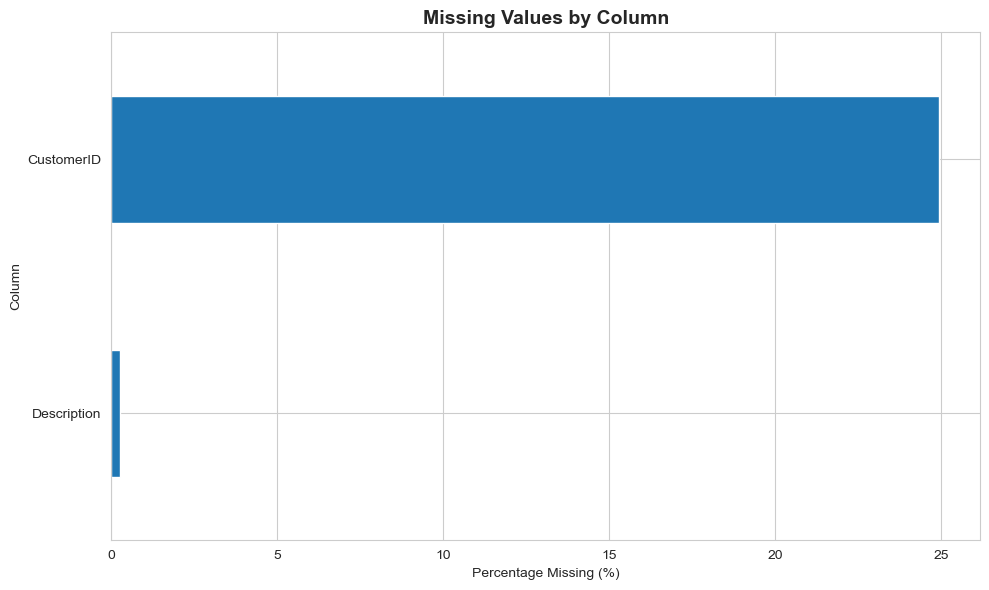

In [3]:
# Missing values analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_data.to_string(index=False))

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
missing_data_all = pd.DataFrame({
    'Column': df.columns,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100)
}).sort_values('Missing_Percentage', ascending=True)

missing_data_all[missing_data_all['Missing_Percentage'] > 0].plot(
    kind='barh', x='Column', y='Missing_Percentage', ax=ax, legend=False
)
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Percentage Missing (%)')
plt.tight_layout()
plt.show()

## 4. Statistical Summary

In [4]:
# Statistical summary for numerical columns
print("=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
print(df.describe().to_string())

# Additional statistics
print("\n" + "="*80)
print("ADDITIONAL STATISTICS")
print("="*80)
for col in df.select_dtypes(include=[np.number]).columns:
    print(f"\n{col}:")
    print(f"  Skewness: {df[col].skew():.4f}")
    print(f"  Kurtosis: {df[col].kurtosis():.4f}")
    print(f"  Variance: {df[col].var():.2f}")

STATISTICAL SUMMARY
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000

ADDITIONAL STATISTICS

Quantity:
  Skewness: -0.2641
  Kurtosis: 119769.1600
  Variance: 47559.39

UnitPrice:
  Skewness: 186.5070
  Kurtosis: 59005.7191
  Variance: 9362.47

CustomerID:
  Skewness: 0.0298
  Kurtosis: -1.1800
  Variance: 2936426.00


## 5. Target Variable Analysis (Quantity)

QUANTITY DISTRIBUTION ANALYSIS (TARGET VARIABLE)
Mean Quantity: 9.55
Median Quantity: 3.00
Std Dev: 218.08
Min: -80995
Max: 80995
Negative Quantities: 10624
Zero Quantities: 0


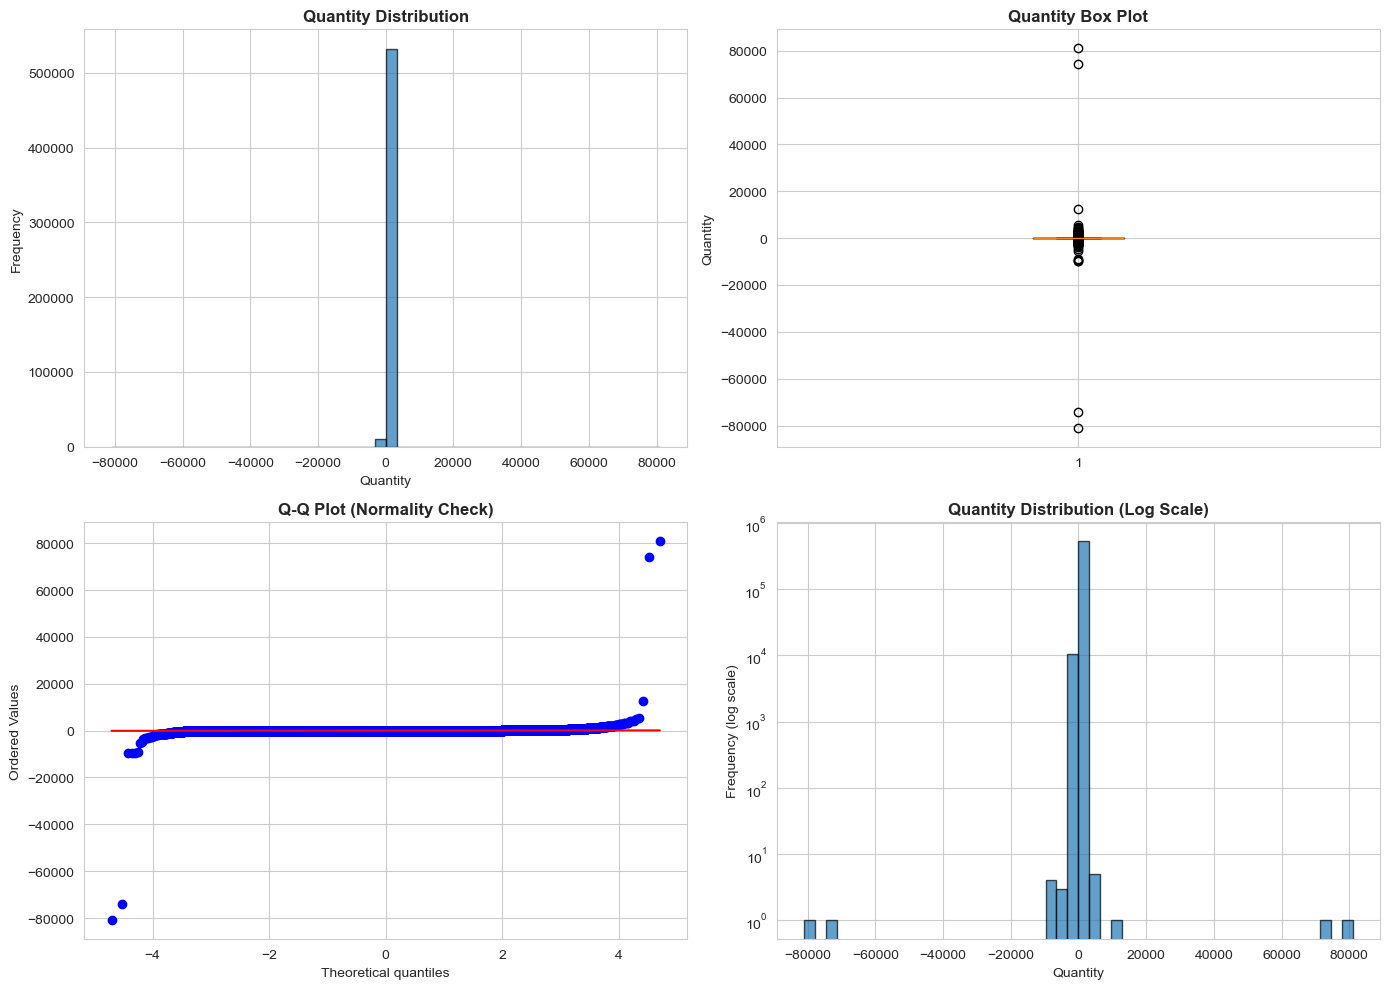

In [5]:
# Analyze the target variable - Quantity
print("=" * 80)
print("QUANTITY DISTRIBUTION ANALYSIS (TARGET VARIABLE)")
print("=" * 80)
print(f"Mean Quantity: {df['Quantity'].mean():.2f}")
print(f"Median Quantity: {df['Quantity'].median():.2f}")
print(f"Std Dev: {df['Quantity'].std():.2f}")
print(f"Min: {df['Quantity'].min()}")
print(f"Max: {df['Quantity'].max()}")
print(f"Negative Quantities: {(df['Quantity'] < 0).sum()}")
print(f"Zero Quantities: {(df['Quantity'] == 0).sum()}")

# Visualize quantity distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(df['Quantity'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Quantity Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Frequency')

# Box plot
axes[0, 1].boxplot(df['Quantity'], vert=True)
axes[0, 1].set_title('Quantity Box Plot', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Quantity')

# Q-Q plot
from scipy import stats
stats.probplot(df['Quantity'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')

# Log-scale histogram
axes[1, 1].hist(df['Quantity'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Quantity Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Quantity')
axes[1, 1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

## 6. Unit Price Analysis

UNIT PRICE ANALYSIS
Mean Unit Price: £4.61
Median Unit Price: £2.08
Std Dev: £96.76
Min: £-11062.06
Max: £38970.00
Negative Prices: 2
Zero Prices: 2515


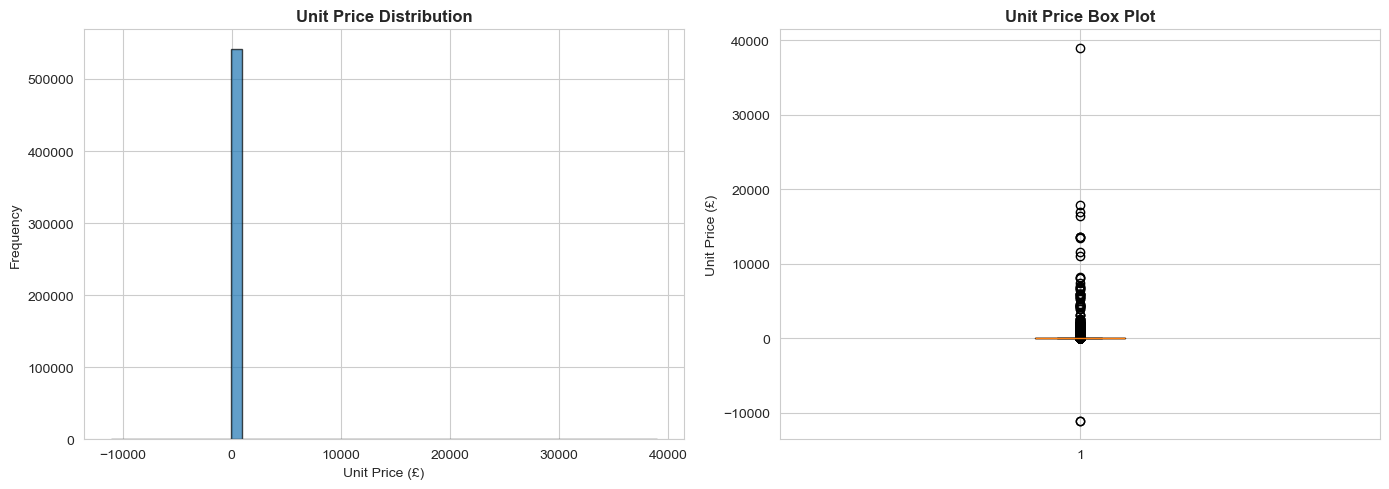

In [6]:
# Analyze Unit Price
print("=" * 80)
print("UNIT PRICE ANALYSIS")
print("=" * 80)
print(f"Mean Unit Price: £{df['UnitPrice'].mean():.2f}")
print(f"Median Unit Price: £{df['UnitPrice'].median():.2f}")
print(f"Std Dev: £{df['UnitPrice'].std():.2f}")
print(f"Min: £{df['UnitPrice'].min():.2f}")
print(f"Max: £{df['UnitPrice'].max():.2f}")
print(f"Negative Prices: {(df['UnitPrice'] < 0).sum()}")
print(f"Zero Prices: {(df['UnitPrice'] == 0).sum()}")

# Visualize Unit Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['UnitPrice'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Unit Price Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Unit Price (£)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['UnitPrice'], vert=True)
axes[1].set_title('Unit Price Box Plot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Unit Price (£)')

plt.tight_layout()
plt.show()

## 7. Categorical Variables Analysis

In [7]:
# Categorical Variables Analysis
print("=" * 80)
print("CATEGORICAL VARIABLES ANALYSIS")
print("=" * 80)

print(f"\nUnique Countries: {df['Country'].nunique()}")
print(f"\nTop 10 Countries:")
top_countries = df['Country'].value_counts().head(10)
print(top_countries)

print(f"\n\nUnique Products (StockCode): {df['StockCode'].nunique()}")
print(f"\nTop 10 Products:")
top_products = df['StockCode'].value_counts().head(10)
print(top_products)

print(f"\n\nUnique Invoices: {df['InvoiceNo'].nunique()}")
print(f"\nUnique Customers: {df['CustomerID'].nunique()}")

CATEGORICAL VARIABLES ANALYSIS

Unique Countries: 38

Top 10 Countries:
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


Unique Products (StockCode): 4070

Top 10 Products:
StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
84879     1502
22720     1477
22197     1476
21212     1385
20727     1350
Name: count, dtype: int64


Unique Invoices: 25900

Unique Customers: 4372


## 8. Country and Product Distribution

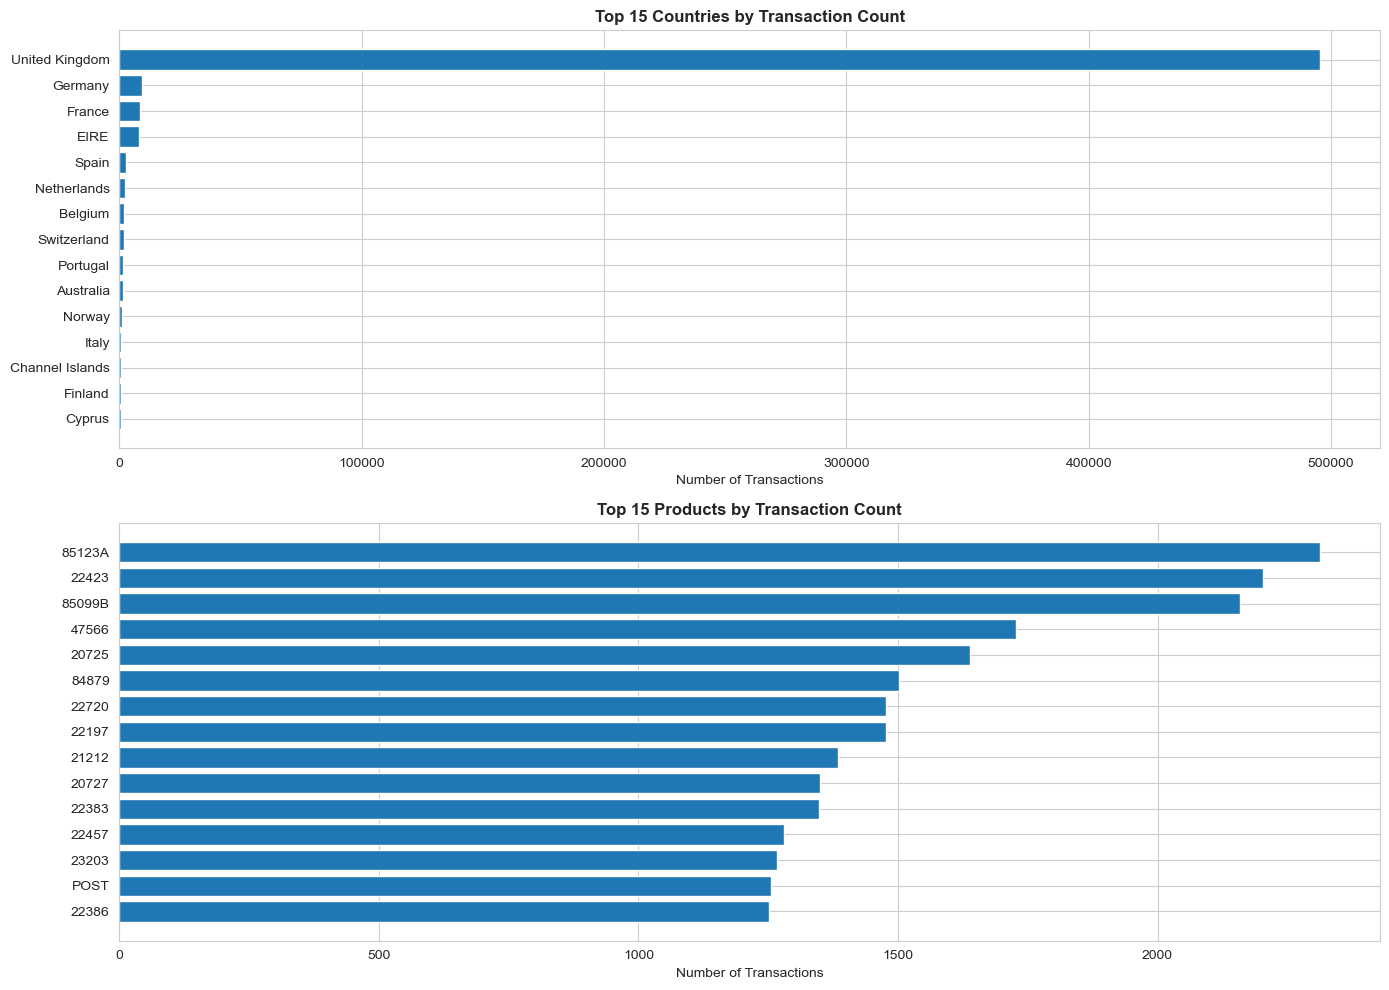

In [8]:
# Visualize top countries
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top countries
top_countries = df['Country'].value_counts().head(15)
axes[0].barh(range(len(top_countries)), top_countries.values)
axes[0].set_yticks(range(len(top_countries)))
axes[0].set_yticklabels(top_countries.index)
axes[0].set_xlabel('Number of Transactions')
axes[0].set_title('Top 15 Countries by Transaction Count', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Top products
top_products = df['StockCode'].value_counts().head(15)
axes[1].barh(range(len(top_products)), top_products.values)
axes[1].set_yticks(range(len(top_products)))
axes[1].set_yticklabels(top_products.index)
axes[1].set_xlabel('Number of Transactions')
axes[1].set_title('Top 15 Products by Transaction Count', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Time Series Analysis

In [9]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')

print("=" * 80)
print("TIME SERIES ANALYSIS")
print("=" * 80)
print(f"Date Range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Date Range Duration: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")

# Extract time features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

print(f"\nYears in data: {sorted(df['Year'].unique())}")
print(f"\nTransactions by Month:")
print(df['Month'].value_counts().sort_index())

TIME SERIES ANALYSIS
Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Date Range Duration: 373 days

Years in data: [np.int32(2010), np.int32(2011)]

Transactions by Month:
Month
1     35147
2     27707
3     36748
4     29916
5     37030
6     36874
7     39518
8     35284
9     50226
10    60742
11    84711
12    68006
Name: count, dtype: int64


## 10. Time-Based Patterns

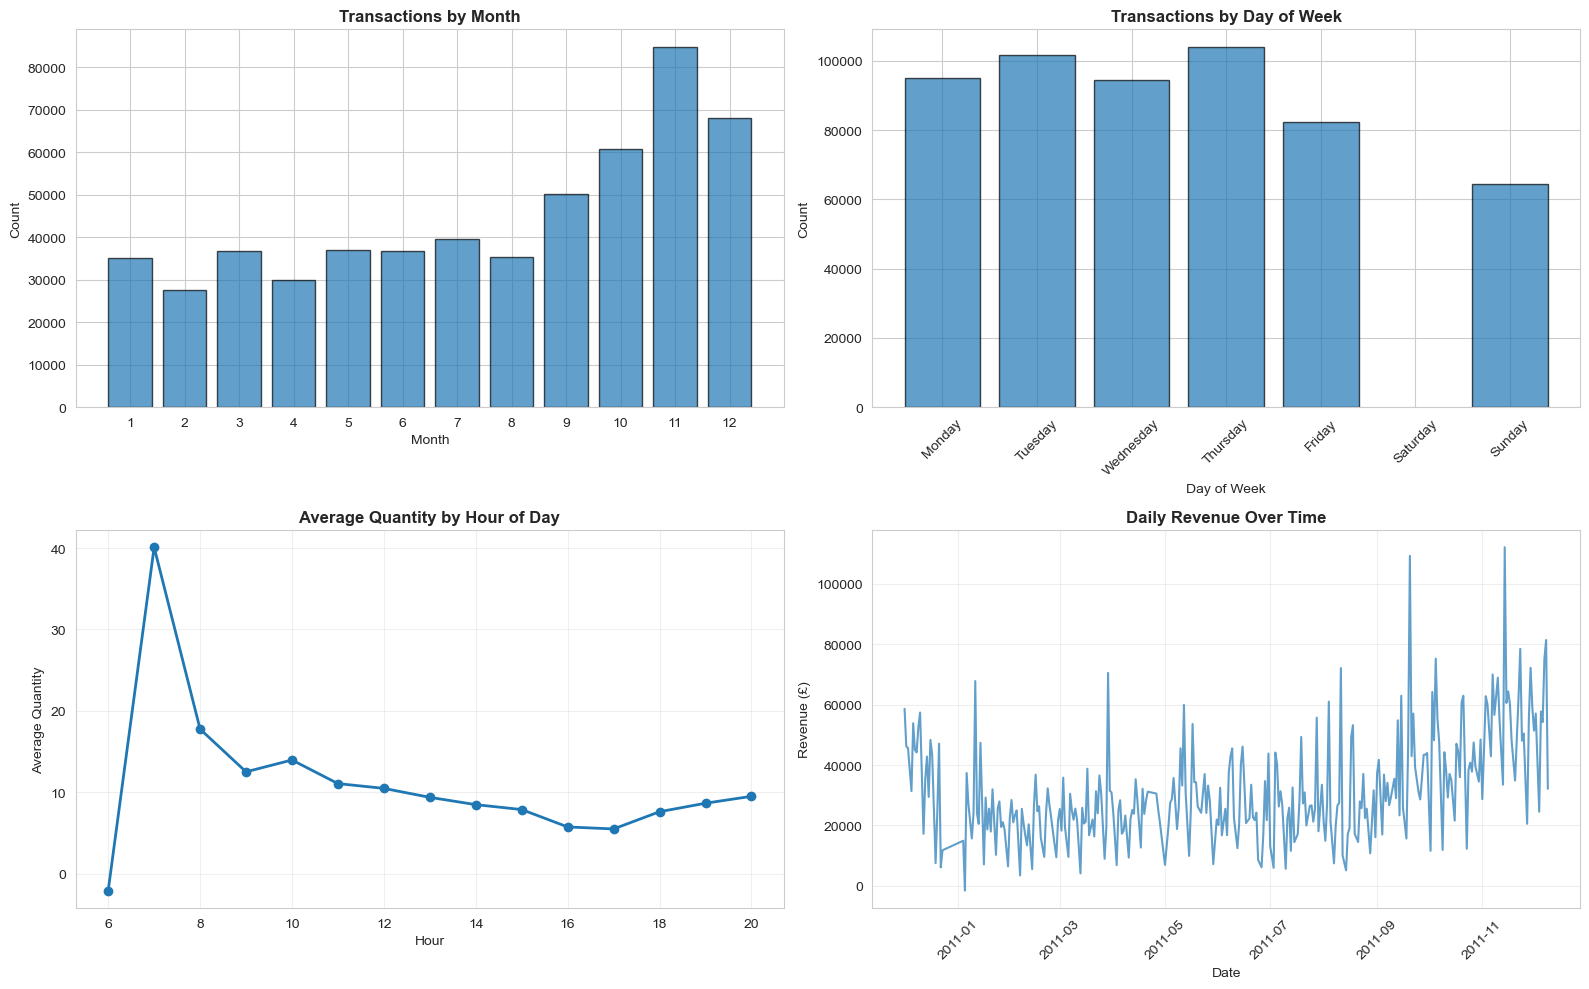

In [10]:
# Visualize time-based patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Transactions by month
monthly_trans = df.groupby('Month').size()
axes[0, 0].bar(monthly_trans.index, monthly_trans.values, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Transactions by Month', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticks(range(1, 13))

# Transactions by day of week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_trans = df.groupby('DayOfWeek').size()
axes[0, 1].bar(daily_trans.index, daily_trans.values, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Transactions by Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_names, rotation=45)

# Quantity by hour
hourly_qty = df.groupby('Hour')['Quantity'].mean()
axes[1, 0].plot(hourly_qty.index, hourly_qty.values, marker='o', linestyle='-', linewidth=2)
axes[1, 0].set_title('Average Quantity by Hour of Day', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Average Quantity')
axes[1, 0].grid(True, alpha=0.3)

# Revenue over time (daily)
df['Revenue'] = df['Quantity'] * df['UnitPrice']
daily_revenue = df.groupby(df['InvoiceDate'].dt.date)['Revenue'].sum()
axes[1, 1].plot(daily_revenue.index, daily_revenue.values, linewidth=1.5, alpha=0.7)
axes[1, 1].set_title('Daily Revenue Over Time', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Revenue (£)')
axes[1, 1].grid(True, alpha=0.3)
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## 11. Correlation Analysis

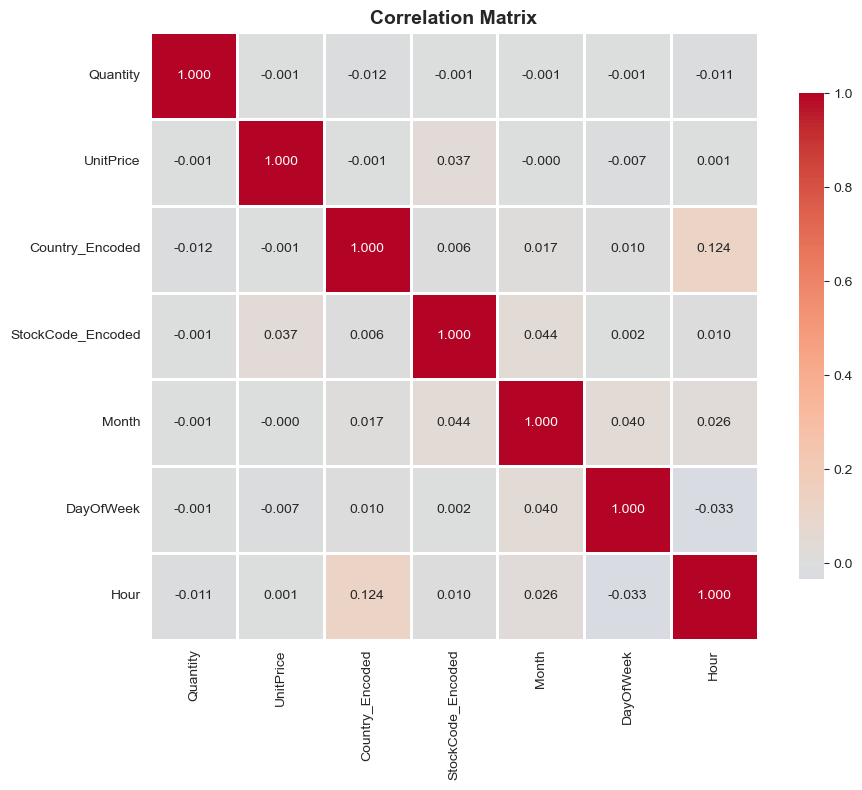

CORRELATION WITH QUANTITY (TARGET VARIABLE)
Quantity             1.000000
DayOfWeek           -0.000904
Month               -0.001116
UnitPrice           -0.001235
StockCode_Encoded   -0.001379
Hour                -0.011268
Country_Encoded     -0.012056
Name: Quantity, dtype: float64


In [11]:
# Prepare data for correlation analysis
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()

# Encode categorical variables for correlation
le_country = LabelEncoder()
le_stock = LabelEncoder()

df_corr['Country_Encoded'] = le_country.fit_transform(df_corr['Country'])
df_corr['StockCode_Encoded'] = le_stock.fit_transform(df_corr['StockCode'])

# Select numerical columns for correlation
correlation_cols = ['Quantity', 'UnitPrice', 'Country_Encoded', 'StockCode_Encoded', 'Month', 'DayOfWeek', 'Hour']
correlation_matrix = df_corr[correlation_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlation with target variable
print("=" * 80)
print("CORRELATION WITH QUANTITY (TARGET VARIABLE)")
print("=" * 80)
quantity_corr = correlation_matrix['Quantity'].sort_values(ascending=False)
print(quantity_corr)

## 12. Outlier Detection

OUTLIER DETECTION (IQR Method)

Quantity:
  Total Outliers: 58619
  Percentage: 10.82%
  Lower Bound: -12.50
  Upper Bound: 23.50

UnitPrice:
  Total Outliers: 39627
  Percentage: 7.31%
  Lower Bound: -3.07
  Upper Bound: 8.45


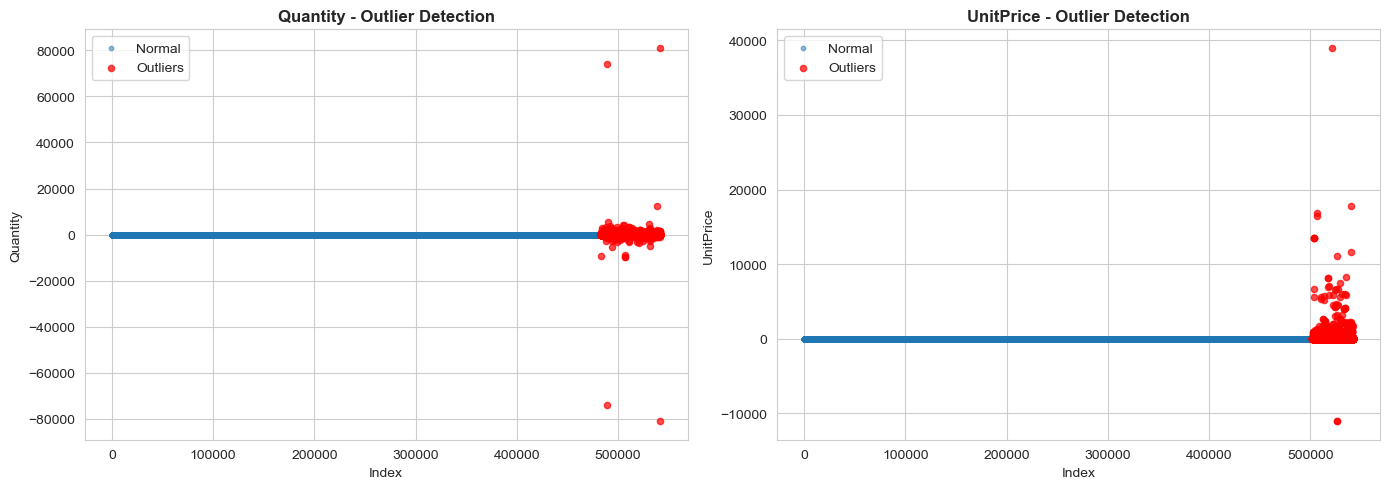

In [12]:
# Outlier detection using IQR method
print("=" * 80)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 80)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

for col in ['Quantity', 'UnitPrice']:
    outliers = detect_outliers_iqr(df_corr, col)
    print(f"\n{col}:")
    print(f"  Total Outliers: {outliers.sum()}")
    print(f"  Percentage: {(outliers.sum() / len(df_corr) * 100):.2f}%")
    print(f"  Lower Bound: {df_corr[col].quantile(0.25) - 1.5 * (df_corr[col].quantile(0.75) - df_corr[col].quantile(0.25)):.2f}")
    print(f"  Upper Bound: {df_corr[col].quantile(0.75) + 1.5 * (df_corr[col].quantile(0.75) - df_corr[col].quantile(0.25)):.2f}")

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(['Quantity', 'UnitPrice']):
    outliers = detect_outliers_iqr(df_corr, col)
    axes[idx].scatter(range(len(df_corr[~outliers])), df_corr[~outliers][col], alpha=0.5, label='Normal', s=10)
    axes[idx].scatter(range(len(df_corr[~outliers]), len(df_corr)), df_corr[outliers][col], alpha=0.7, color='red', label='Outliers', s=20)
    axes[idx].set_title(f'{col} - Outlier Detection', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Index')
    axes[idx].set_ylabel(col)
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 13. Customer Analysis

CUSTOMER ANALYSIS

Total Customers: 4372

Customer Statistics:
       Transactions       Quantity        Revenue
count   4372.000000    4372.000000    4372.000000
mean      93.053294    1122.344007    1898.459701
std      232.471608    4672.790720    8219.345141
min        1.000000    -303.000000   -4287.630000
25%       17.000000     153.000000     293.362500
50%       42.000000     365.000000     648.075000
75%      102.000000     962.250000    1611.725000
max     7983.000000  196719.000000  279489.020000

Top 10 Customers by Revenue:
            Transactions  Quantity    Revenue
CustomerID                                   
14646.0             2085    196719  279489.02
18102.0              433     64122  256438.49
17450.0              351     69029  187482.17
14911.0             5903     77180  132572.62
12415.0              778     77242  123725.45
14156.0             1420     57025  113384.14
17511.0             1076     63012   88125.38
16684.0              281     49390   65892.

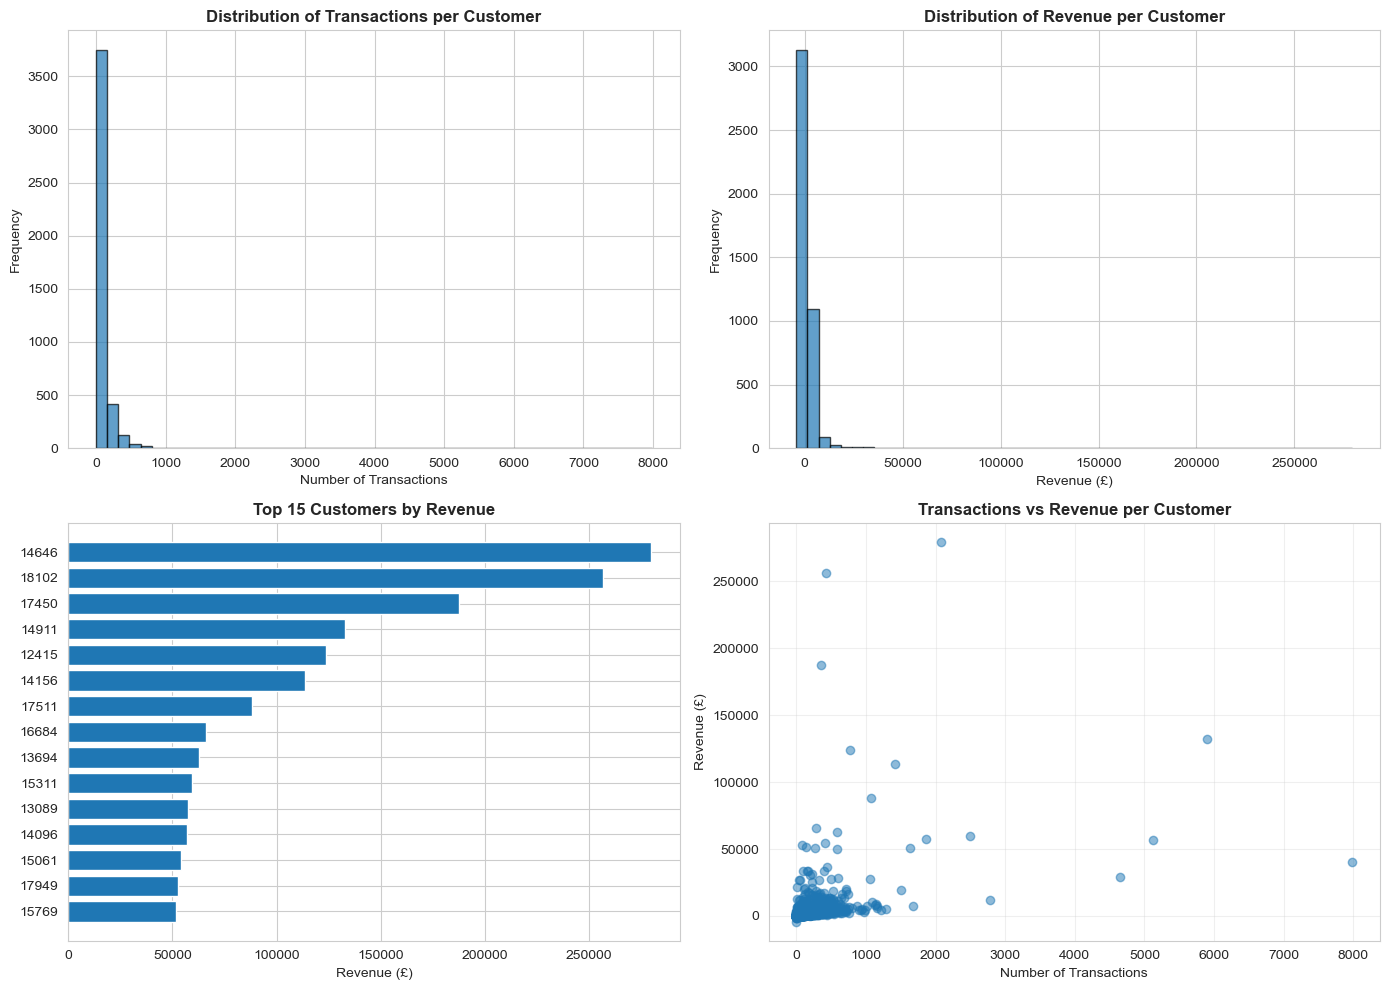

In [13]:
# Customer-level analysis
print("=" * 80)
print("CUSTOMER ANALYSIS")
print("=" * 80)

# Remove records with missing CustomerID for this analysis
df_customers = df[df['CustomerID'].notna()].copy()

customer_stats = df_customers.groupby('CustomerID').agg({
    'InvoiceNo': 'count',
    'Quantity': 'sum',
    'Revenue': 'sum'
}).rename(columns={'InvoiceNo': 'Transactions'})

print(f"\nTotal Customers: {len(customer_stats)}")
print(f"\nCustomer Statistics:")
print(customer_stats.describe())

print(f"\nTop 10 Customers by Revenue:")
top_customers = customer_stats.sort_values('Revenue', ascending=False).head(10)
print(top_customers)

# Visualize customer distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of transactions per customer
axes[0, 0].hist(customer_stats['Transactions'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Transactions per Customer', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Transactions')
axes[0, 0].set_ylabel('Frequency')

# Distribution of revenue per customer
axes[0, 1].hist(customer_stats['Revenue'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Revenue per Customer', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Revenue (£)')
axes[0, 1].set_ylabel('Frequency')

# Top 15 customers by revenue
top_15_customers = customer_stats.sort_values('Revenue', ascending=False).head(15)
axes[1, 0].barh(range(len(top_15_customers)), top_15_customers['Revenue'].values)
axes[1, 0].set_yticks(range(len(top_15_customers)))
axes[1, 0].set_yticklabels(top_15_customers.index.astype(int))
axes[1, 0].set_xlabel('Revenue (£)')
axes[1, 0].set_title('Top 15 Customers by Revenue', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()

# Transactions vs Revenue scatter
axes[1, 1].scatter(customer_stats['Transactions'], customer_stats['Revenue'], alpha=0.5)
axes[1, 1].set_title('Transactions vs Revenue per Customer', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Transactions')
axes[1, 1].set_ylabel('Revenue (£)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Product Analysis

PRODUCT ANALYSIS

Total Products: 4070

Product Statistics:
       Transactions      Quantity    UnitPrice        Revenue
count   4070.000000   4070.000000  4070.000000    4070.000000
mean     133.147174   1271.855037     4.930757    2395.024062
std      199.903331   3052.458716   129.191143    7931.603222
min        1.000000 -14418.000000 -3687.353333 -221520.500000
25%       14.000000     32.000000     1.104659      95.197500
50%       62.000000    300.500000     2.251385     612.650000
75%      167.000000   1279.500000     4.238953    2087.657500
max     2313.000000  56450.000000  7324.784706  206245.480000

Top 10 Products by Revenue:
           Transactions  Quantity   UnitPrice    Revenue
StockCode                                               
DOT                 710      1707  290.495859  206245.48
22423              2203     12980   13.781484  164762.19
47566              1727     18022    5.778587   98302.98
85123A             2313     38830    3.103238   97894.50
85099B     

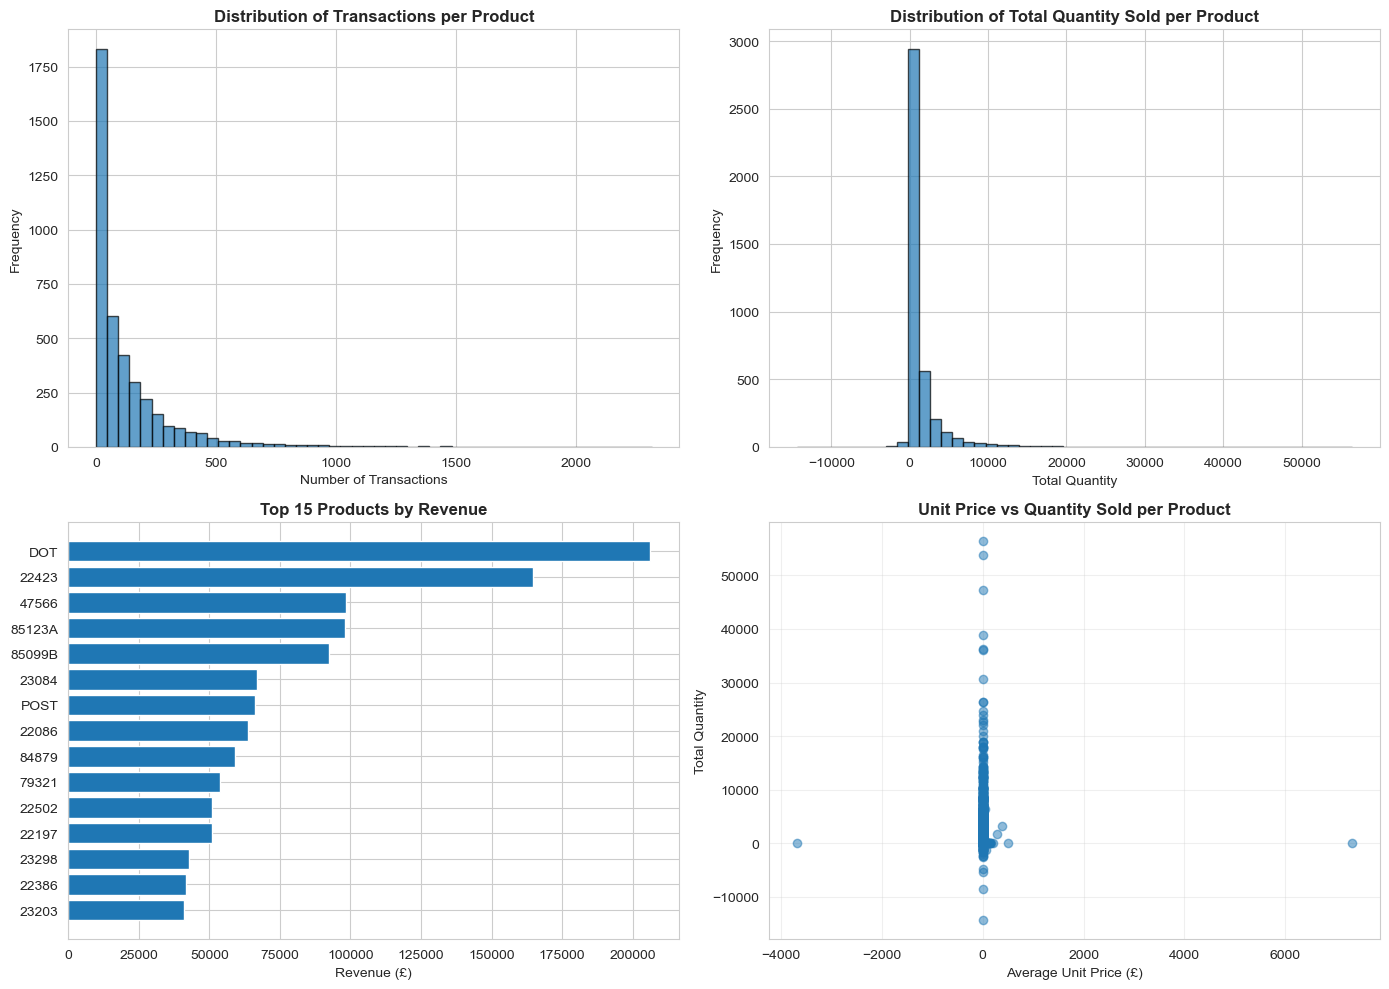

In [14]:
# Product-level analysis
print("=" * 80)
print("PRODUCT ANALYSIS")
print("=" * 80)

product_stats = df.groupby('StockCode').agg({
    'InvoiceNo': 'count',
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'Revenue': 'sum'
}).rename(columns={'InvoiceNo': 'Transactions'})

print(f"\nTotal Products: {len(product_stats)}")
print(f"\nProduct Statistics:")
print(product_stats.describe())

print(f"\nTop 10 Products by Revenue:")
top_products_revenue = product_stats.sort_values('Revenue', ascending=False).head(10)
print(top_products_revenue)

# Visualize product distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of transactions per product
axes[0, 0].hist(product_stats['Transactions'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Transactions per Product', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Transactions')
axes[0, 0].set_ylabel('Frequency')

# Distribution of total quantity sold per product
axes[0, 1].hist(product_stats['Quantity'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Total Quantity Sold per Product', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Total Quantity')
axes[0, 1].set_ylabel('Frequency')

# Top 15 products by revenue
top_15_products = product_stats.sort_values('Revenue', ascending=False).head(15)
axes[1, 0].barh(range(len(top_15_products)), top_15_products['Revenue'].values)
axes[1, 0].set_yticks(range(len(top_15_products)))
axes[1, 0].set_yticklabels(top_15_products.index)
axes[1, 0].set_xlabel('Revenue (£)')
axes[1, 0].set_title('Top 15 Products by Revenue', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()

# Unit Price vs Quantity scatter
axes[1, 1].scatter(product_stats['UnitPrice'], product_stats['Quantity'], alpha=0.5)
axes[1, 1].set_title('Unit Price vs Quantity Sold per Product', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Average Unit Price (£)')
axes[1, 1].set_ylabel('Total Quantity')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Key Insights and Summary

In [15]:
print("=" * 80)
print("KEY INSIGHTS - EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 80)

insights = f"""
1. DATASET OVERVIEW:
   • Total Records: {len(df):,}
   • Total Features: {len(df.columns)}
   • Date Range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}
   • Duration: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days

2. MISSING DATA:
   • Description: {df['Description'].isnull().sum()} missing values ({df['Description'].isnull().sum()/len(df)*100:.2f}%)
   • CustomerID: {df['CustomerID'].isnull().sum()} missing values ({df['CustomerID'].isnull().sum()/len(df)*100:.2f}%)

3. TARGET VARIABLE (QUANTITY):
   • Mean: {df['Quantity'].mean():.2f} units
   • Median: {df['Quantity'].median():.2f} units
   • Range: {df['Quantity'].min()} to {df['Quantity'].max()} units
   • Std Dev: {df['Quantity'].std():.2f}
   • Skewness: {df['Quantity'].skew():.4f} (Highly right-skewed)

4. UNIT PRICE:
   • Mean: £{df['UnitPrice'].mean():.2f}
   • Median: £{df['UnitPrice'].median():.2f}
   • Range: £{df['UnitPrice'].min():.2f} to £{df['UnitPrice'].max():.2f}

5. CATEGORICAL INSIGHTS:
   • Unique Countries: {df['Country'].nunique()}
   • Top Country: {df['Country'].value_counts().index[0]} ({df['Country'].value_counts().iloc[0]:,} transactions)
   • Unique Products: {df['StockCode'].nunique()}
   • Unique Customers: {df[df['CustomerID'].notna()]['CustomerID'].nunique()}
   • Unique Invoices: {df['InvoiceNo'].nunique()}

6. CUSTOMER ANALYSIS:
   • Average Transactions per Customer: {customer_stats['Transactions'].mean():.2f}
   • Average Revenue per Customer: £{customer_stats['Revenue'].mean():.2f}
   • Max Revenue Customer: £{customer_stats['Revenue'].max():.2f}

7. PRODUCT ANALYSIS:
   • Average Transactions per Product: {product_stats['Transactions'].mean():.2f}
   • Average Total Quantity per Product: {product_stats['Quantity'].mean():.2f}
   • Top Product Revenue: £{product_stats['Revenue'].max():.2f}

8. TIME-BASED PATTERNS:
   • Busiest Month: {df['Month'].value_counts().index[0]} ({df[df['Month']==df['Month'].value_counts().index[0]].shape[0]:,} transactions)
   • Busiest Day: {day_names[df['DayOfWeek'].value_counts().index[0]]} ({df[df['DayOfWeek']==df['DayOfWeek'].value_counts().index[0]].shape[0]:,} transactions)
   • Peak Hour: {df['Hour'].value_counts().index[0]}:00 ({df[df['Hour']==df['Hour'].value_counts().index[0]].shape[0]:,} transactions)

9. DATA QUALITY:
   • Quantity Outliers (IQR): {detect_outliers_iqr(df_corr, 'Quantity').sum():,} ({detect_outliers_iqr(df_corr, 'Quantity').sum()/len(df_corr)*100:.2f}%)
   • Price Outliers (IQR): {detect_outliers_iqr(df_corr, 'UnitPrice').sum():,} ({detect_outliers_iqr(df_corr, 'UnitPrice').sum()/len(df_corr)*100:.2f}%)

10. FEATURE CORRELATIONS WITH QUANTITY:
    • Unit Price: {correlation_matrix.loc['Quantity', 'UnitPrice']:.4f}
    • Country: {correlation_matrix.loc['Quantity', 'Country_Encoded']:.4f}
    • StockCode: {correlation_matrix.loc['Quantity', 'StockCode_Encoded']:.4f}
    • Hour: {correlation_matrix.loc['Quantity', 'Hour']:.4f}
"""

print(insights)

KEY INSIGHTS - EXPLORATORY DATA ANALYSIS SUMMARY

1. DATASET OVERVIEW:
   • Total Records: 541,909
   • Total Features: 14
   • Date Range: 2010-12-01 to 2011-12-09
   • Duration: 373 days

2. MISSING DATA:
   • Description: 1454 missing values (0.27%)
   • CustomerID: 135080 missing values (24.93%)

3. TARGET VARIABLE (QUANTITY):
   • Mean: 9.55 units
   • Median: 3.00 units
   • Range: -80995 to 80995 units
   • Std Dev: 218.08
   • Skewness: -0.2641 (Highly right-skewed)

4. UNIT PRICE:
   • Mean: £4.61
   • Median: £2.08
   • Range: £-11062.06 to £38970.00

5. CATEGORICAL INSIGHTS:
   • Unique Countries: 38
   • Top Country: United Kingdom (495,478 transactions)
   • Unique Products: 4070
   • Unique Customers: 4372
   • Unique Invoices: 25900

6. CUSTOMER ANALYSIS:
   • Average Transactions per Customer: 93.05
   • Average Revenue per Customer: £1898.46
   • Max Revenue Customer: £279489.02

7. PRODUCT ANALYSIS:
   • Average Transactions per Product: 133.15
   • Average Total Quan

## Recommendations for Model Development

Based on the EDA, here are recommendations for the machine learning model:

1. **Data Preprocessing:**
   - Handle missing CustomerID values (consider interpolation or removal)
   - Remove or flag outliers in Quantity and UnitPrice
   - Consider log transformation for skewed distributions

2. **Feature Engineering:**
   - Create time-based features (Month, Day of Week, Hour, Season)
   - Create customer-based features (frequency, RFM analysis)
   - Create product-based features (category, popularity)
   - Encode categorical variables (Country, StockCode)

3. **Model Selection:**
   - Given the right-skewed distribution, consider ensemble methods (Random Forest, XGBoost)
   - Log-transform the target variable for linear models
   - Consider regression with regularization to handle outliers

4. **Data Considerations:**
   - High class imbalance in countries and products - may need stratified sampling
   - Strong temporal patterns suggest time-series features are valuable
   - Customer and product effects are significant predictors